# 📑 Importing Required Libraries

In [34]:
import os
import cv2 
import pandas as pd
import numpy as np
from glob import glob

import matplotlib.pylab as plt

from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping
from keras.utils import image_dataset_from_directory

from keras.applications.vgg16 import VGG16
from keras.applications.resnet50 import ResNet50

import warnings
warnings.filterwarnings('ignore')

# 📖 Reading Images Data

In [19]:
dog_file = glob("../input/cat-and-dog/training_set/training_set/dogs/*.jpg")
cat_file = glob("../input/cat-and-dog/training_set/training_set/cats/*.jpg")

In [20]:
# this is used to list a names of the subdirectories of the file (training/testing)
os.listdir("/kaggle/input/cat-and-dog/training_set/training_set")

['dogs', 'cats']

In [21]:
def dir_info(path, filename): 
    path = path
    print(f"{filename}")
    for folder in os.listdir(path):
        folder_path = os.path.join(path,folder)
        if os.path.isdir(folder_path):
            list_of_elements = os.listdir(os.path.join(path,folder))
            print(f"folder:{folder}")
            print(f"number of elements:{len(list_of_elements)}")
            print("******************")
        else:
            print(f"{folder_path} is not a directory")

In [22]:
train_path = "/kaggle/input/cat-and-dog/training_set/training_set"
test_path = "/kaggle/input/cat-and-dog/test_set/test_set"
dir_info(train_path, "Training")
dir_info(test_path, "Testing")

Training
folder:dogs
number of elements:4006
******************
folder:cats
number of elements:4001
******************
Testing
folder:dogs
number of elements:1013
******************
folder:cats
number of elements:1012
******************


In [23]:
def path_info(directory):
    img_path = []
    img_cate = []
    for file in os.listdir(directory):
        path = os.path.join(directory, file)
        img_path.append(path)
        img_cate.append(file.split('.')[0])
    return img_path, img_cate

In [24]:
path, cate = path_info(train_path)
img_info = pd.DataFrame({'Category':cate, 'img_paths': path})

In [25]:
img_info

,Category,img_paths
0,dogs,/kaggle/input/cat-and-dog/training_set/trainin...
1,cats,/kaggle/input/cat-and-dog/training_set/trainin...


# 🖼️ Display

In [26]:
img_cv2 = cv2.imread(cat_file[20])
img_cv2.shape

# we have to change the color of the picutre since OpenCV read the image
# in BGR format
img_cv2 = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)

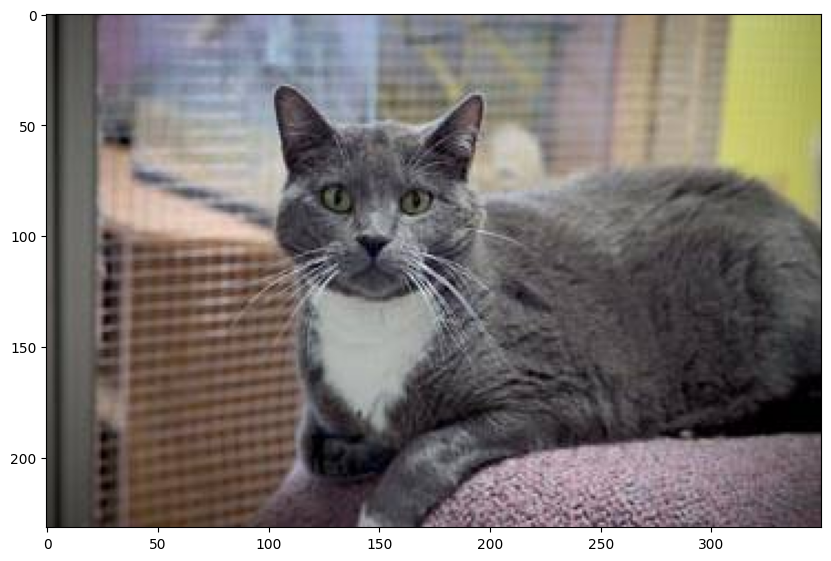

In [27]:
fig, ax = plt.subplots(figsize=(10,10))

plt.imshow(img_cv2)
plt.show()

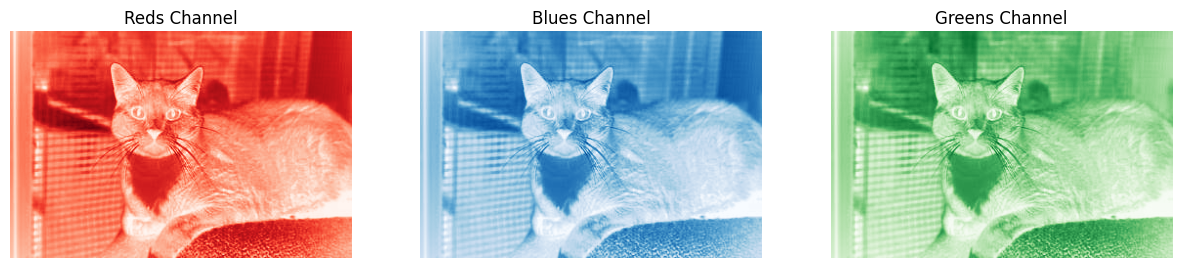

In [28]:
fig, axs = plt.subplots(1, 3, figsize = (15,5))

colors = {0:"Reds", 1:"Blues", 2:"Greens"}

for index, value in colors.items():
    axs[index].imshow(img_cv2[:, :, index], cmap = value)
    axs[index].axis("off")
    axs[index].set_title(f"{value} Channel")
plt.show()

# 🧪 Image Loading & Preprocessing

In Image processing, there 3 main processes to be done: 
*  Image Normalization
*  Gray Scaling (If required)
*  Image Resizing


## 🔍 Image Resizing 

In [29]:
# we used this class so we can resize each image in specified manner, without having complex code

train = image_dataset_from_directory(
    directory = '/kaggle/input/cat-and-dog/training_set/training_set',
    labels='inferred', # inferred means get the names from the sub-dir
    label_mode='int', # since its a binary classification
    #batch_size=32,
    image_size=(256, 256)
)


test = image_dataset_from_directory(
    directory = '/kaggle/input/cat-and-dog/test_set/test_set',
    labels='inferred', # inferred means get the names from the sub-dir 
    label_mode='int', # since its a binary classification
    #batch_size=32,
    image_size=(256, 256)
)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


In [30]:
type(test)

tensorflow.python.data.ops.prefetch_op._PrefetchDataset

In [31]:
for images, labels in test.take(1):
    print("Image batch shape: ", images.shape)
    print("Label batch shape: ", labels.shape)
    print("Labels: ", labels.numpy())

Image batch shape:  (32, 256, 256, 3)
Label batch shape:  (32,)
Labels:  [0 0 1 1 0 1 0 1 1 0 0 1 1 1 1 0 0 1 0 0 0 0 0 1 1 1 0 0 1 0 0 1]


## Image Normalization

**Image Normalization** is the process of rescaling your data to ensure that each input
feature (pixel, in the image case) has a similar data distribution.

In [32]:
def img_normalizer(img, label): 
    tf.cast(img/255., tf.float32)
    return img,label
train = train.map(img_normalizer)
test = test.map(img_normalizer)

In [35]:
# Convert TensorFlow Dataset to NumPy arrays
images = []
labels = []

for img_batch, label_batch in train:
    images.append(img_batch.numpy())
    labels.append(label_batch.numpy())

# Convert lists to NumPy arrays
images = np.concatenate(images, axis=0)
labels = np.concatenate(labels, axis=0)

Xtrain, Xtest, ytrain, ytest = train_test_split(images, labels, test_size=0.1, random_state=42)


In [36]:
# Calculate the split size
dataset_size = len(list(train))
train_size = int(0.9 * dataset_size)
val_size = dataset_size - train_size

# Split the dataset
train_dataset = train.take(train_size)
validation_dataset = train.skip(train_size)

# 🤖 Modelling

### In this section, we will going to use some Transfare learning model or pretrained models such **VGG16** and user defined model


**Transfer learning** is the transfer of the knowledge (feature maps) that the network has acquired from one task,
where we have a large amount of data, to a new task where data is not abundantly available. It is generally used
where a neural network model is first trained on a problem similar to the problem that is being solved. One or
more layers from the trained model are then used in a new model trained on the problem of interest.

and the figure below will illustrate that:
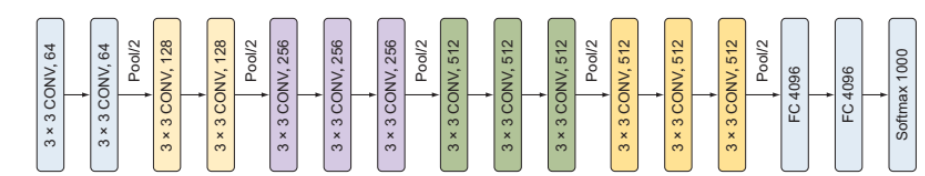

## 🅲🅽🅽 User Predifined Model
A convolutional neural network **(CNN)** is a type of artificial neural network
(Deep Learning) used in image recognition and processing that is specifically
designed to process pixel data.

**CNN** like any neural network, contains some main parts:

1. Input layer: which is the images we want to train.
2. Conv layer which act like a feature finder window that slides over the image pixel by pixel to extract meaningful features that identify the objects in the image.
<ul>
 <li>Feature maps: is the output of each covn layer, and input of the next one.</li>
 <li>Activation Function: also called "Transfare function" which is a function that transfare the data into other way of data.</li>
 <li>Pooling layer: also known as subsampling or down sampling, simple process where we reduce the size or dimensionality of the Feature Map.</li>
</ul>
3. The Fully Connected Layer: the activation function used to produce these probabilities is the Soft Max Function as it turns the outputs of the FC layer (last layer) into probabilities

In [37]:
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=4, padding='same', activation='relu', input_shape=(256, 256, 3)))
model.add(Conv2D(filters=64, kernel_size=4, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(BatchNormalization())


model.add(Conv2D(filters=64, kernel_size=4, padding='same', activation='relu'))
model.add(Conv2D(filters=128, kernel_size=4, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(BatchNormalization())

model.add(Conv2D(filters=128, kernel_size=4, padding='same', activation='relu'))
model.add(Conv2D(filters=256, kernel_size=4, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(BatchNormalization())

model.add(Conv2D(filters=256, kernel_size=4, padding='same', activation='relu'))
model.add(Conv2D(filters=256, kernel_size=4, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(BatchNormalization())

model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(500, activation='relu'))

model.add(Dropout(0.4))
model.add(Dense(400, activation='relu'))

model.add(Dropout(0.3))
model.add(Dense(300, activation='relu'))

model.add(Dropout(0.2))
model.add(Dense(2, activation='sigmoid'))


early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
history = model.fit(Xtrain, ytrain, epochs=30, validation_split=0.1, verbose=1, callbacks=[early_stopping])

## 🆅🅶🅶𝟏𝟔

**VGG16** its a deep convolutional neural networks designed by the Visual Geometry Group (VGG) at the University of Oxford.

**Architecture**: VGG16 consists of 16 weight layers: 13 convolutional layers and 3 fully connected layers.

In [17]:
keras.applications.VGG16(
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=2,
    classifier_activation="sigmoid",
)

NameError: name 'binary_crossentropy' is not defined

## 🆁🅴🆂🅽🅴🆃𝟓𝟎

**ResNet50** is part of the ResNet (Residual Networks) family, introduced by Microsoft Research. It is known for its innovative use of residual connections, which help mitigate the vanishing gradient problem.

**Architecture**: ResNet50 consists of 50 layers, including convolutional layers, batch normalization layers, and identity shortcuts (residual connections).

In [ ]:
keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=2,
    classifier_activation="sigmoid",
)